In [1]:
# ======================================================
# EDA COMPLETO PARA dataset_unificado_semanal.csv
# ======================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Opciones visuales
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.grid'] = True

In [5]:
# ============================================
# 2. Cargar archivos
# ============================================
df_nasa = pd.read_csv("VARIABLES_NASA_CONSOLIDADO_NAL.csv")
df_precio = pd.read_excel("precio_interno_semanal.xlsx")


In [6]:
# ============================================
# 3. Homogeneizar formato de fecha
# ============================================
# Asumimos que ambas tienen columna "fecha" o similar
# Ajusta si tu columna se llama diferente

df_nasa['fecha'] = pd.to_datetime(df_nasa['fecha'], errors='coerce')
df_precio['fecha'] = pd.to_datetime(df_precio['fecha'], errors='coerce')

# Verificar rango de fechas
print(df_nasa['fecha'].min(), df_nasa['fecha'].max())
print(df_precio['fecha'].min(), df_precio['fecha'].max())


2021-01-03 00:00:00 2025-11-02 00:00:00
2021-01-03 00:00:00 2025-11-02 00:00:00


In [8]:
# ============================================
# 2. Revisar estructura de las bases
# ============================================

print("Columnas df_nasa:")
print(df_nasa.columns.tolist())
print("\nTipos de dato df_nasa:")
print(df_nasa.dtypes)

print("\n----------------------------------\n")

print("Columnas df_precio:")
print(df_precio.columns.tolist())
print("\nTipos de dato df_precio:")
print(df_precio.dtypes)


Columnas df_nasa:
['fecha', 'DEPARTAMENTO', 'PRECTOTCORR', 'IMERG_PRECTOT', 'T2M', 'T2M_MAX', 'T2M_MIN', 'RH2M', 'QV2M', 'GWETTOP', 'GWETROOT', 'ALLSKY_SFC_SW_DWN', 'WS2M']

Tipos de dato df_nasa:
fecha                datetime64[ns]
DEPARTAMENTO                 object
PRECTOTCORR                 float64
IMERG_PRECTOT               float64
T2M                         float64
T2M_MAX                     float64
T2M_MIN                     float64
RH2M                        float64
QV2M                        float64
GWETTOP                     float64
GWETROOT                    float64
ALLSKY_SFC_SW_DWN           float64
WS2M                        float64
dtype: object

----------------------------------

Columnas df_precio:
['fecha', 'precio_interno', 'year_iso', 'week_iso']

Tipos de dato df_precio:
fecha             datetime64[ns]
precio_interno           float64
year_iso                   int64
week_iso                   int64
dtype: object


In [9]:
# ============================================
# 4. Asegurar periodicidad semanal
#    (promedia SOLO variables numéricas)
# ============================================

# Variables climáticas numéricas en df_nasa
cols_nasa_num = [
    'PRECTOTCORR', 'IMERG_PRECTOT', 'T2M', 'T2M_MAX', 'T2M_MIN',
    'RH2M', 'QV2M', 'GWETTOP', 'GWETROOT', 'ALLSKY_SFC_SW_DWN', 'WS2M'
]

df_nasa_sem = (
    df_nasa
    .set_index('fecha')[cols_nasa_num]  # excluimos DEPARTAMENTO
    .resample('W-MON')                  # semanas que terminan en lunes
    .mean()
    .reset_index()
)

# df_precio ya viene semanal, pero aseguramos estructura por si hay días sueltos
df_precio_sem = (
    df_precio
    .set_index('fecha')[['precio_interno']]  # solo el precio
    .resample('W-MON')
    .mean()
    .reset_index()
)

# Si quieres volver a tener year_iso y week_iso, los recalculamos aquí:
df_precio_sem['year_iso'] = df_precio_sem['fecha'].dt.isocalendar().year
df_precio_sem['week_iso'] = df_precio_sem['fecha'].dt.isocalendar().week

In [10]:
# ============================================
# 5. Unificar datasets por la fecha
# ============================================
df_final = pd.merge(
    df_nasa_sem,
    df_precio_sem,
    on='fecha',
    how='inner'
)

In [11]:
# ============================================
# 6. Verificar dataset final
# ============================================
print("Forma final del dataset:", df_final.shape)
print(df_final.head())

# ============================================
# 7. Guardar dataset unificado
# ============================================
df_final.to_csv("dataset_unificado_semanal.csv", index=False)
print("Archivo guardado como dataset_unificado_semanal.csv")

Forma final del dataset: (253, 15)
       fecha  PRECTOTCORR  IMERG_PRECTOT        T2M    T2M_MAX    T2M_MIN  \
0 2021-01-04     5.890667            NaN  19.186667  23.254000  16.209333   
1 2021-01-11     5.046000            NaN  18.644857  22.705714  15.584000   
2 2021-01-18     1.051714            NaN  19.771143  24.899143  15.909429   
3 2021-01-25     6.263714            NaN  19.859714  24.964571  16.025429   
4 2021-02-01     3.464286            NaN  20.065714  25.200571  16.176000   

        RH2M       QV2M   GWETTOP  GWETROOT  ALLSKY_SFC_SW_DWN      WS2M  \
0  87.672667  14.342667  0.774000  0.754000          13.996667  0.776000   
1  85.782000  13.549143  0.769714  0.751714          14.466571  0.818857   
2  81.295714  13.654857  0.741143  0.734857          17.718000  0.840286   
3  80.669714  13.604571  0.728857  0.716571          16.238000  0.834286   
4  80.843714  13.807429  0.731714  0.730286          17.927714  0.834857   

   precio_interno  year_iso  week_iso  
0    

In [12]:
# ======================================================
# PARTE 2: EDA COMPLETO PARA dataset_unificado_semanal.csv
# ======================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Opciones visuales
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.grid'] = True

In [13]:
#----------------------------------------------------
# 1. Carga de datos
# ------------------------------------------------------
try:
    df = pd.read_csv("dataset_unificado_semanal.csv")
    print("Archivo 'dataset_unificado_semanal.csv' cargado correctamente.")
except FileNotFoundError:
    print("No se encontró 'dataset_unificado_semanal.csv'. Asegúrate de ejecutarlo en la misma carpeta.")
    
# Convertir fecha a datetime y ordenar
if 'fecha' in df.columns:
    df['fecha'] = pd.to_datetime(df['fecha'], errors='coerce')
    df = df.sort_values('fecha')
else:
    raise ValueError("No se encontró la columna 'fecha' en el dataset.")

print("\nDimensión del dataset:", df.shape)
print("\nColumnas del dataset:")
print(df.columns.tolist())

Archivo 'dataset_unificado_semanal.csv' cargado correctamente.

Dimensión del dataset: (253, 15)

Columnas del dataset:
['fecha', 'PRECTOTCORR', 'IMERG_PRECTOT', 'T2M', 'T2M_MAX', 'T2M_MIN', 'RH2M', 'QV2M', 'GWETTOP', 'GWETROOT', 'ALLSKY_SFC_SW_DWN', 'WS2M', 'precio_interno', 'year_iso', 'week_iso']


In [14]:
# ------------------------------------------------------
# 2. Información general y valores faltantes
# ------------------------------------------------------
print("\n=== INFO GENERAL ===")
print(df.info())

print("\n=== VALORES FALTANTES POR VARIABLE ===")
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    "faltantes": missing,
    "porcentaje": missing_pct
})
print(missing_df)


=== INFO GENERAL ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253 entries, 0 to 252
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   fecha              253 non-null    datetime64[ns]
 1   PRECTOTCORR        253 non-null    float64       
 2   IMERG_PRECTOT      0 non-null      float64       
 3   T2M                253 non-null    float64       
 4   T2M_MAX            253 non-null    float64       
 5   T2M_MIN            253 non-null    float64       
 6   RH2M               253 non-null    float64       
 7   QV2M               253 non-null    float64       
 8   GWETTOP            253 non-null    float64       
 9   GWETROOT           253 non-null    float64       
 10  ALLSKY_SFC_SW_DWN  253 non-null    float64       
 11  WS2M               253 non-null    float64       
 12  precio_interno     253 non-null    float64       
 13  year_iso           253 non-null    int64   

In [15]:

# ------------------------------------------------------
# 3. Estadísticas descriptivas
# ------------------------------------------------------
print("\n=== ESTADÍSTICAS DESCRIPTIVAS ===")
desc = df.describe().T
print(desc)

# Guardar tablas de soporte
missing_df.to_csv("eda_missing_values.csv")
desc.to_csv("eda_descriptivos.csv")
print("\nTablas de soporte guardadas: 'eda_missing_values.csv' y 'eda_descriptivos.csv'")


=== ESTADÍSTICAS DESCRIPTIVAS ===
                   count                 mean                  min  \
fecha                253  2023-06-05 00:00:00  2021-01-04 00:00:00   
PRECTOTCORR        253.0             5.193816             0.288571   
IMERG_PRECTOT        0.0                  NaN                  NaN   
T2M                253.0            19.588491            18.009429   
T2M_MAX            253.0            24.205427            22.039143   
T2M_MIN            253.0            16.168285               14.226   
RH2M               253.0            84.038012            70.536286   
QV2M               253.0             14.00744            11.857714   
GWETTOP            253.0             0.772912                0.636   
GWETROOT           253.0             0.769911             0.638857   
ALLSKY_SFC_SW_DWN  253.0            15.527506            12.191714   
WS2M               253.0             0.863478                0.528   
precio_interno     253.0        1982179.77301       105

In [16]:

# ------------------------------------------------------
# 4. Series de tiempo principales
# ------------------------------------------------------
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Precio interno
precio_col_candidates = [c for c in num_cols if "precio" in c.lower()]
if precio_col_candidates:
    precio_col = precio_col_candidates[0]
else:
    precio_col = None
    print("\n⚠ No se encontró una columna que parezca ser 'precio'. Revisa el nombre en el dataset.")

# Precipitación principal
precip_candidates = [c for c in num_cols if "prec" in c.lower()]
if precip_candidates:
    precip_col = precip_candidates[0]
else:
    precip_col = None
    print("\n⚠ No se encontró una columna de precipitación. Revisa nombres 'PRECTOTCORR' o similares.")


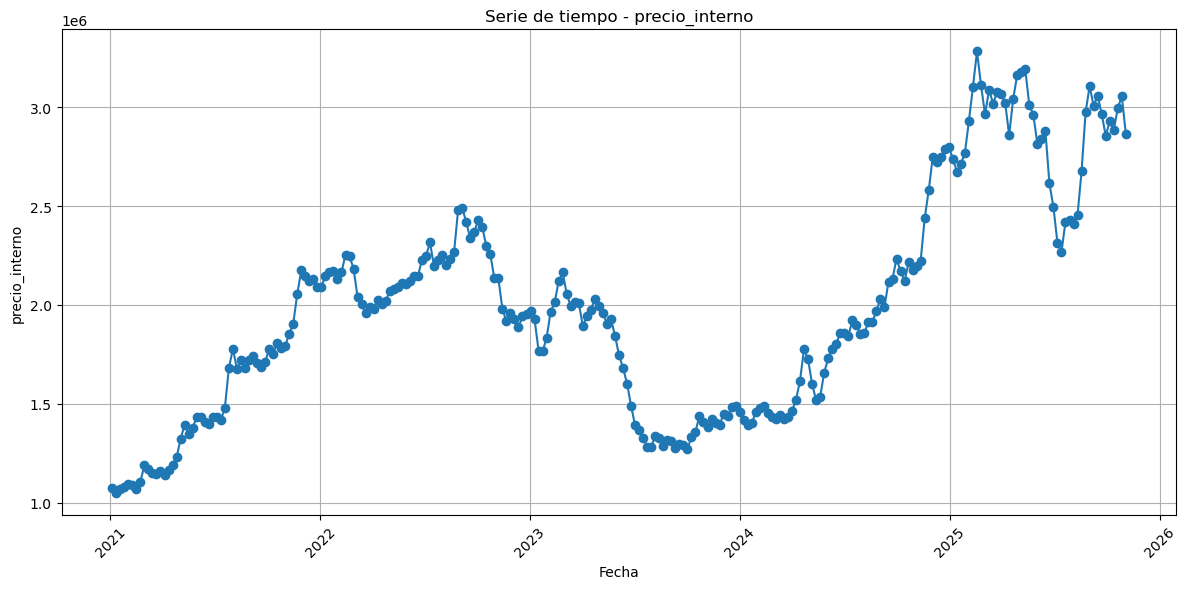

In [17]:

# Gráfico serie de tiempo: precio
if precio_col:
    plt.figure()
    plt.plot(df['fecha'], df[precio_col], marker='o', linestyle='-')
    plt.title(f"Serie de tiempo - {precio_col}")
    plt.xlabel("Fecha")
    plt.ylabel(precio_col)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

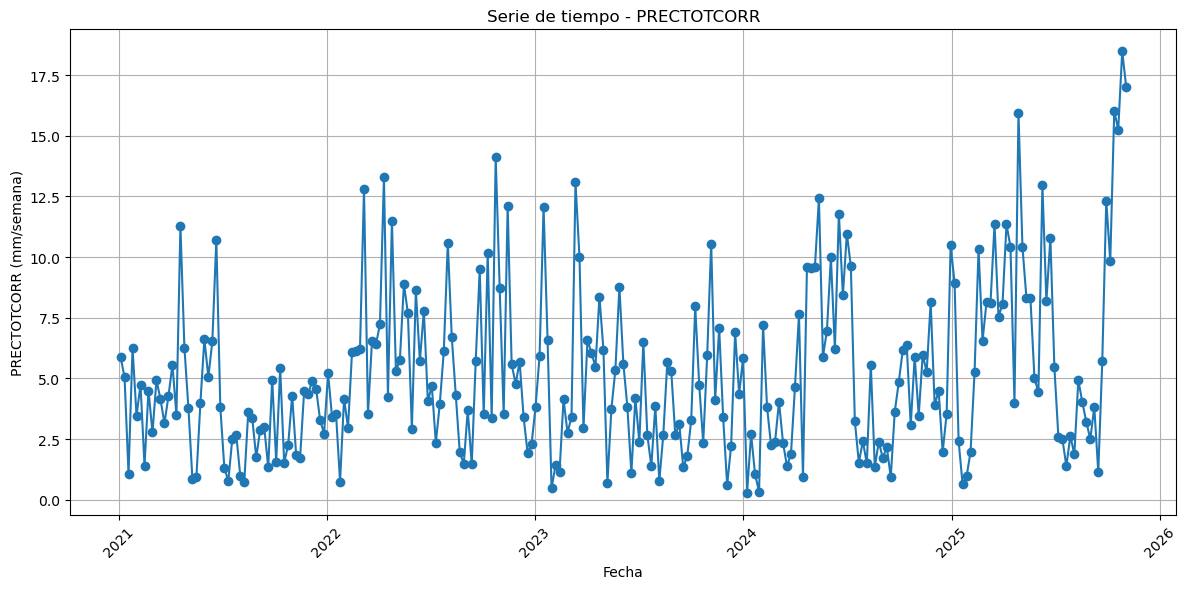

In [18]:
# Gráfico serie de tiempo: precipitación
if precip_col:
    plt.figure()
    plt.plot(df['fecha'], df[precip_col], marker='o', linestyle='-')
    plt.title(f"Serie de tiempo - {precip_col}")
    plt.xlabel("Fecha")
    plt.ylabel(precip_col + " (mm/semana)")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

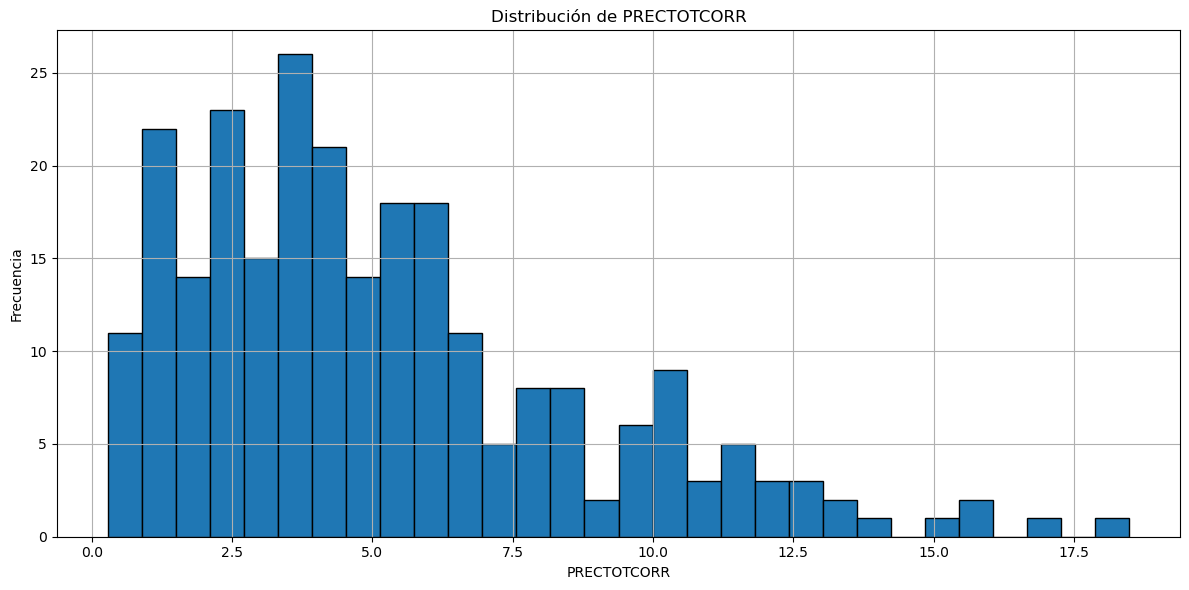

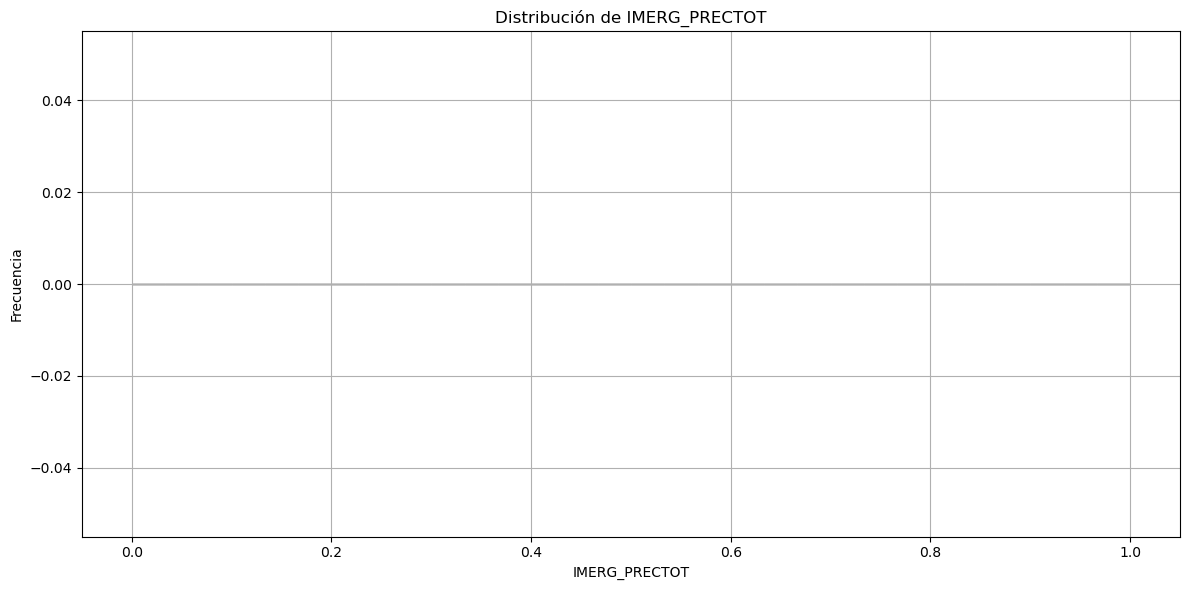

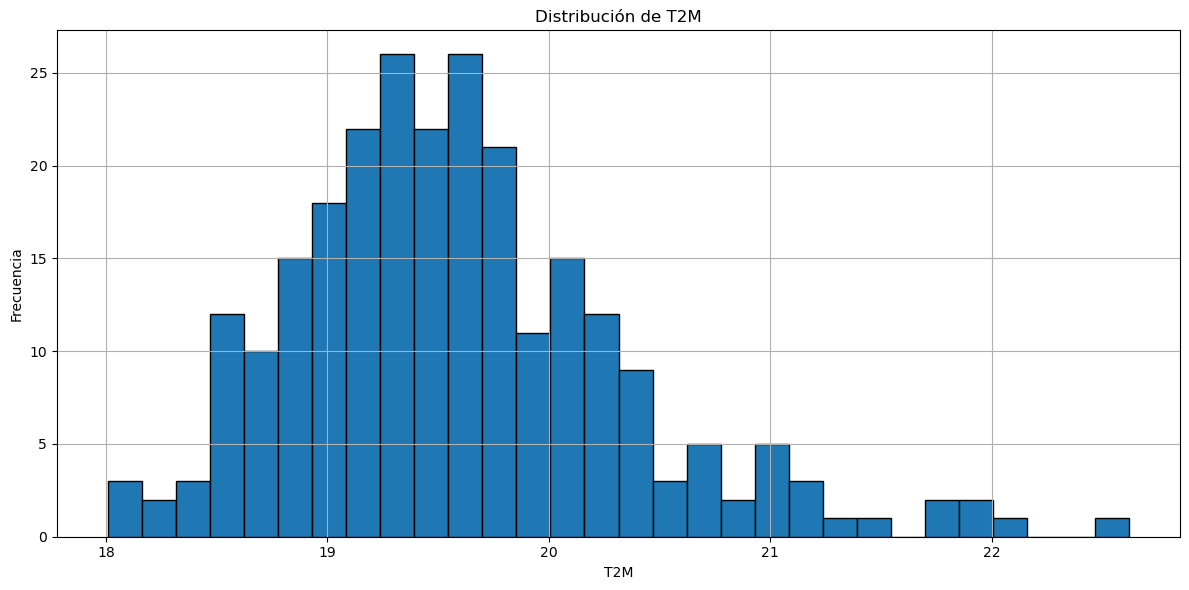

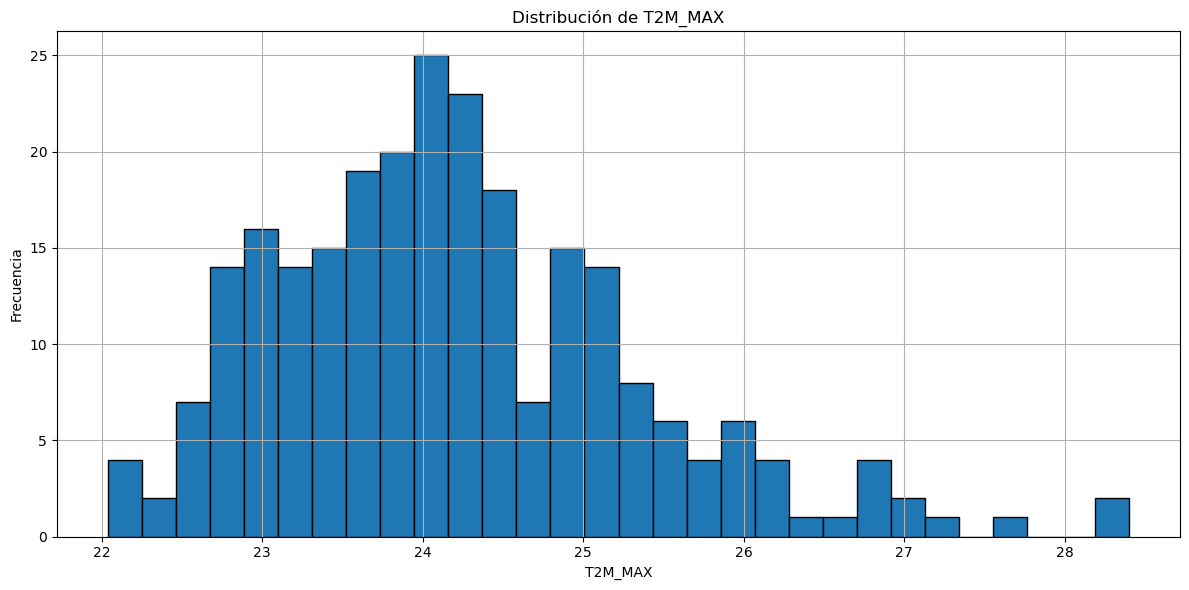

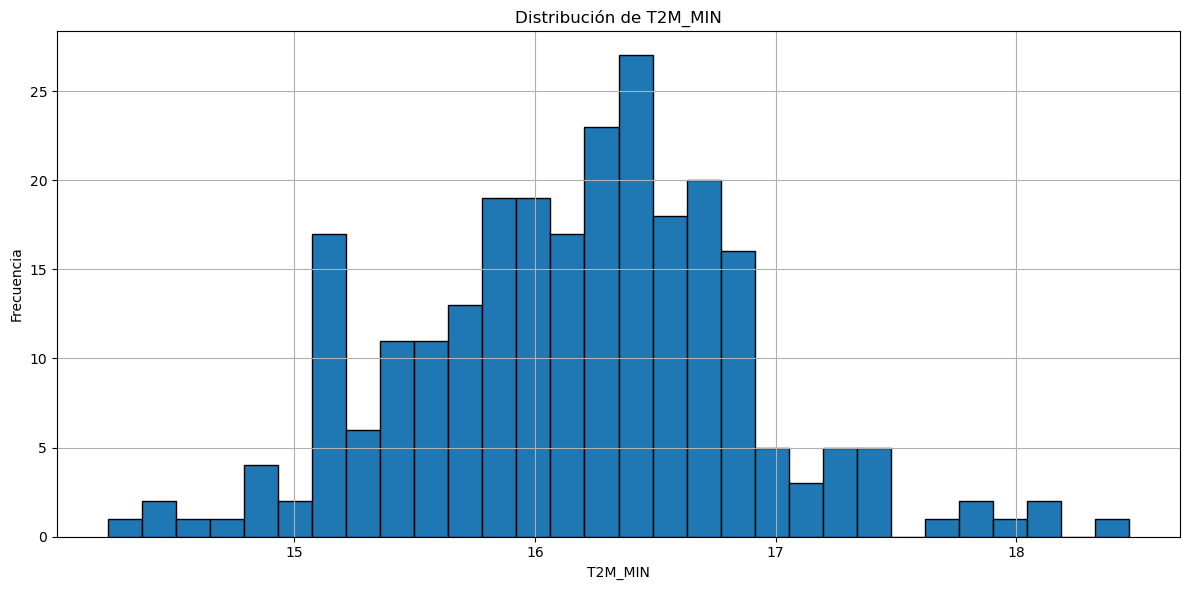

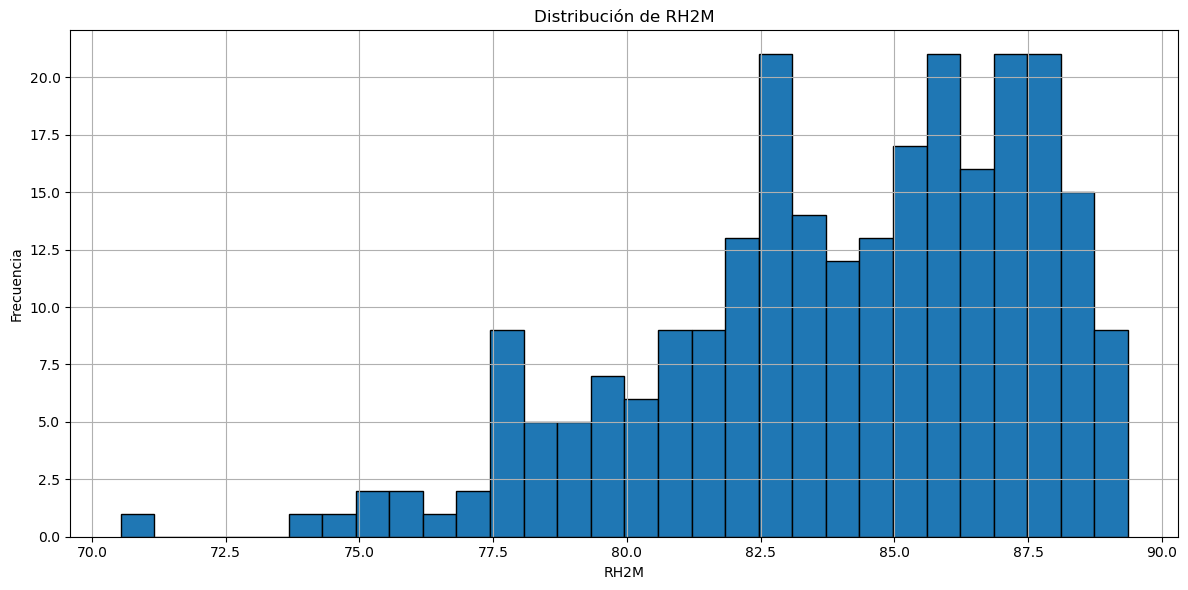

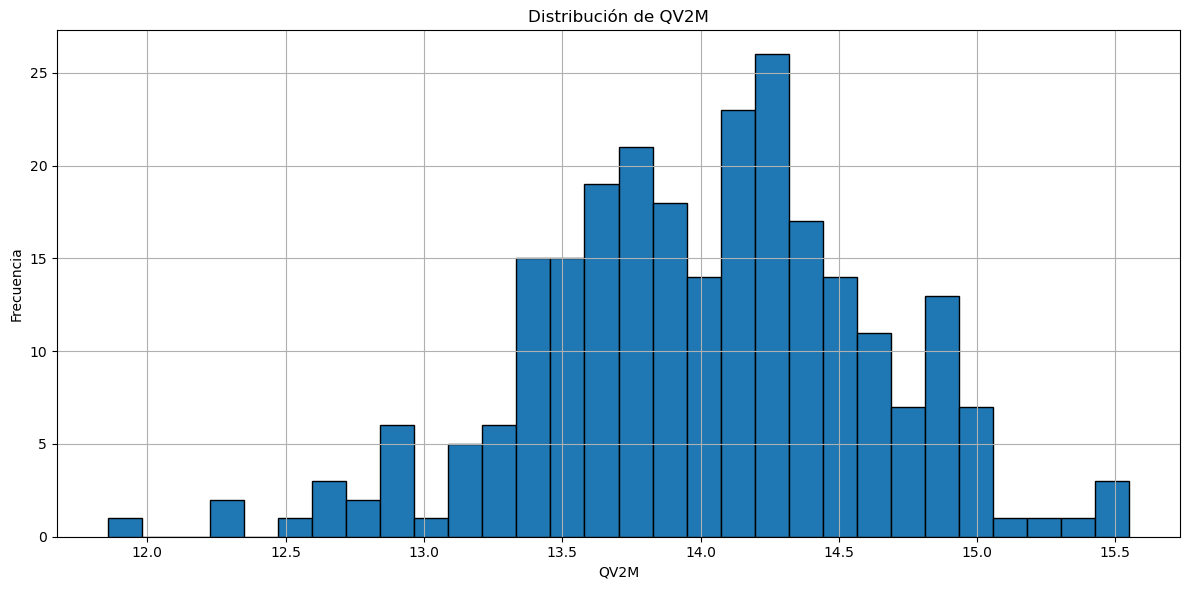

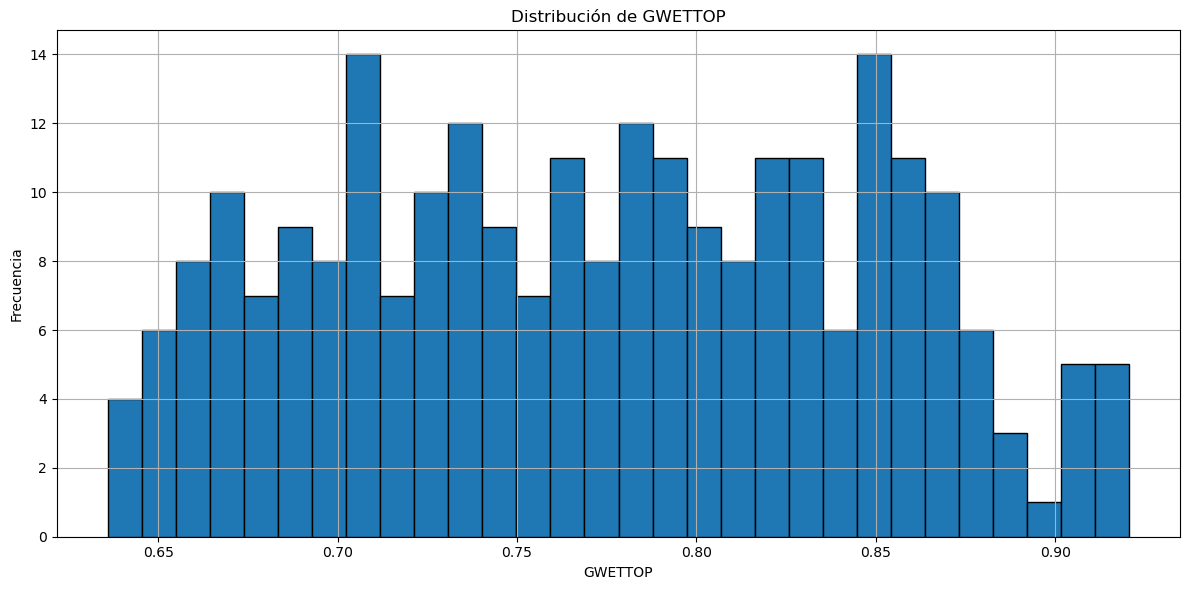

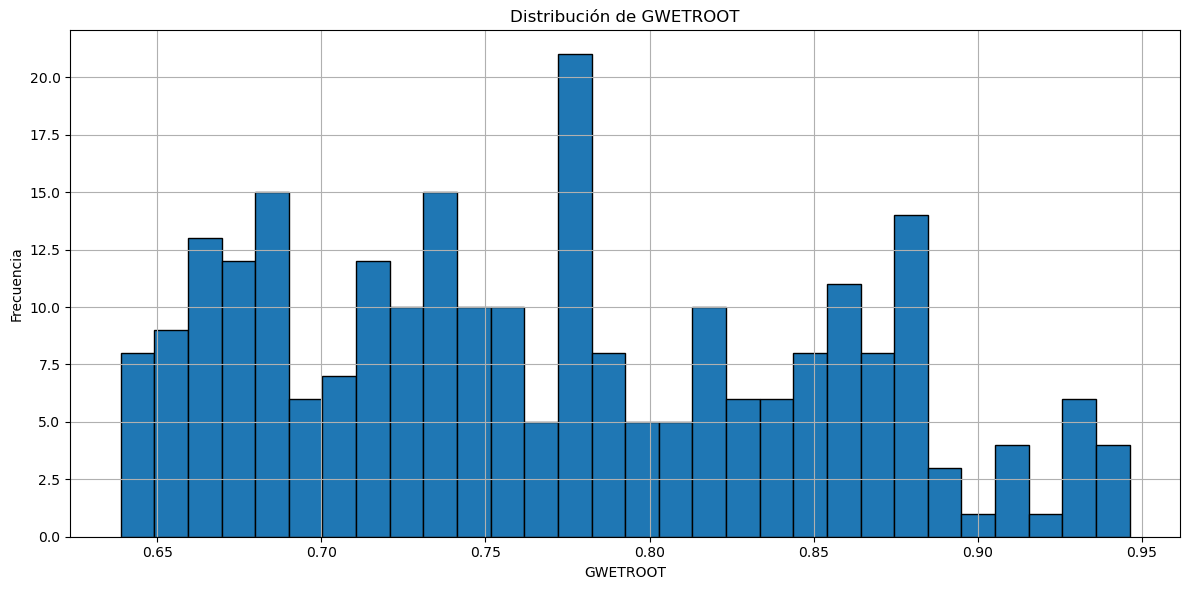

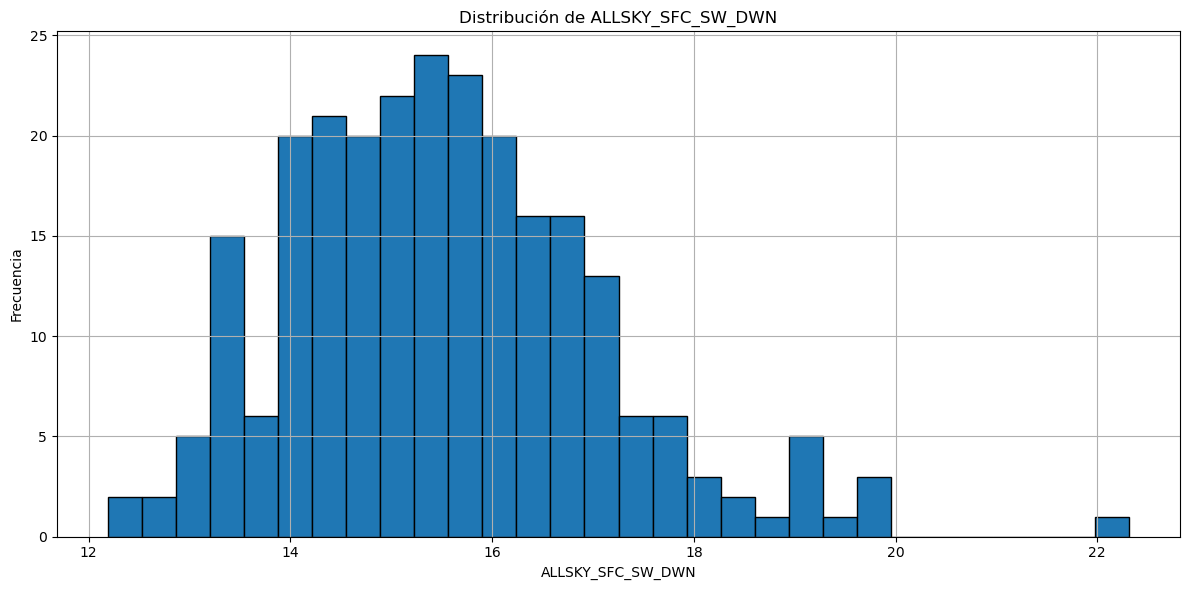

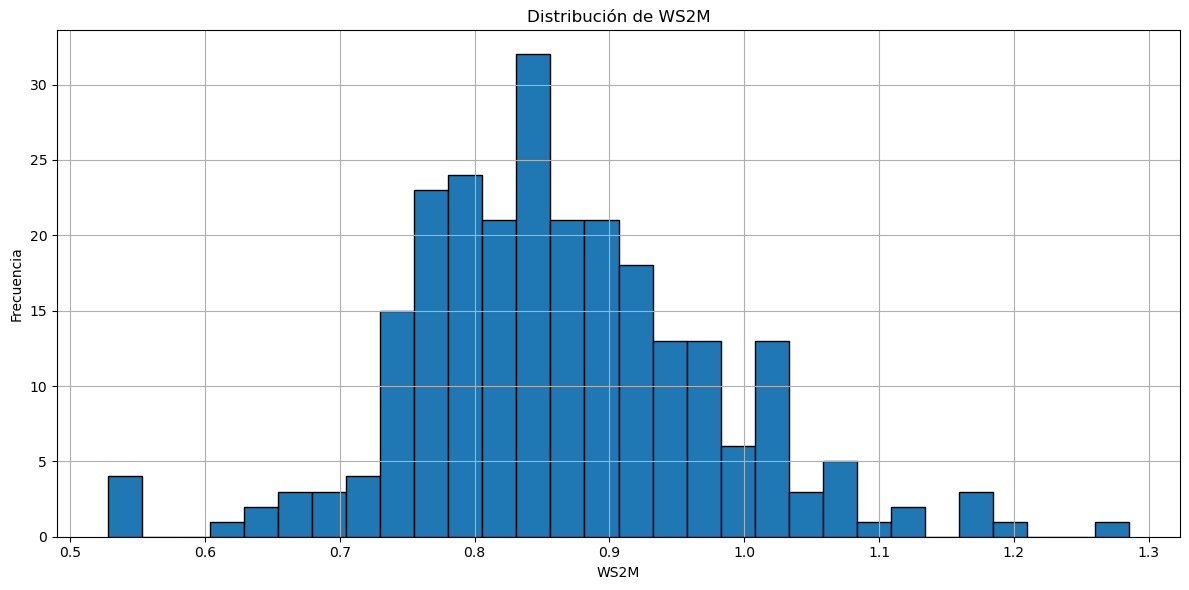

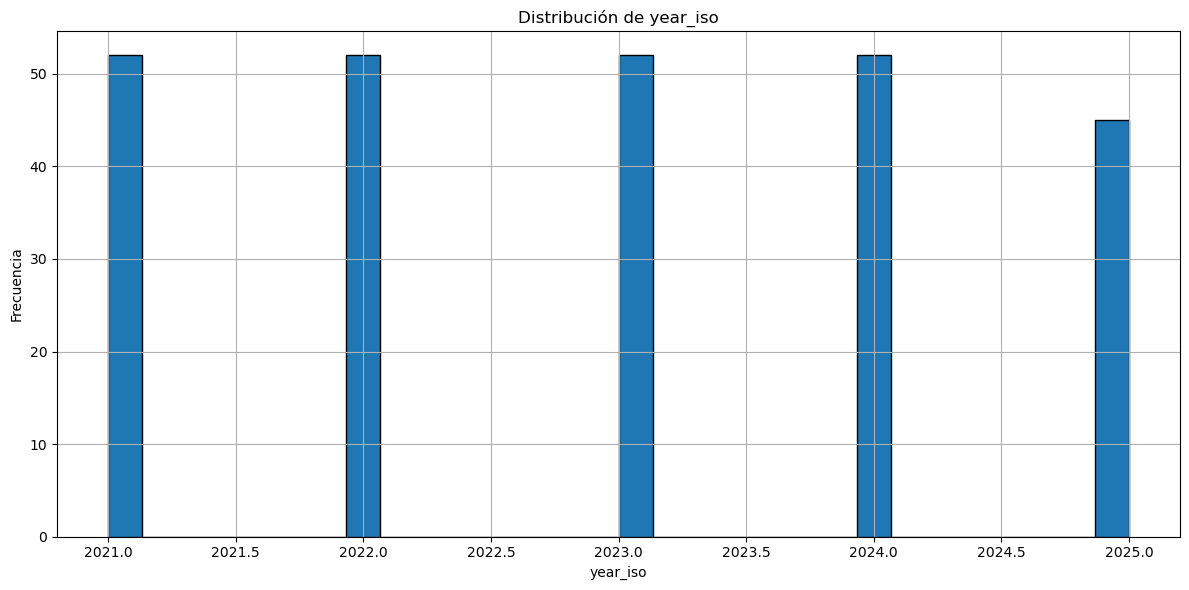

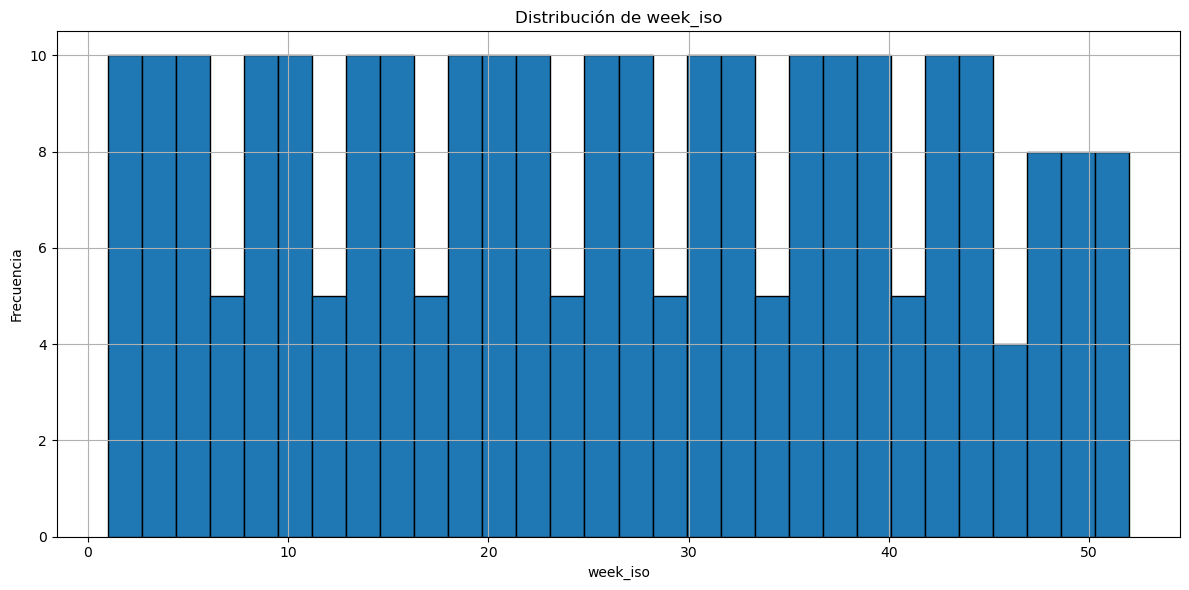

In [19]:
# ------------------------------------------------------
# 5. Distribuciones (histogramas) variables climáticas
# ------------------------------------------------------
climate_cols = [c for c in num_cols if c != precio_col]

for col in climate_cols:
    plt.figure()
    plt.hist(df[col].dropna(), bins=30, edgecolor='k')
    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.tight_layout()
    plt.show()


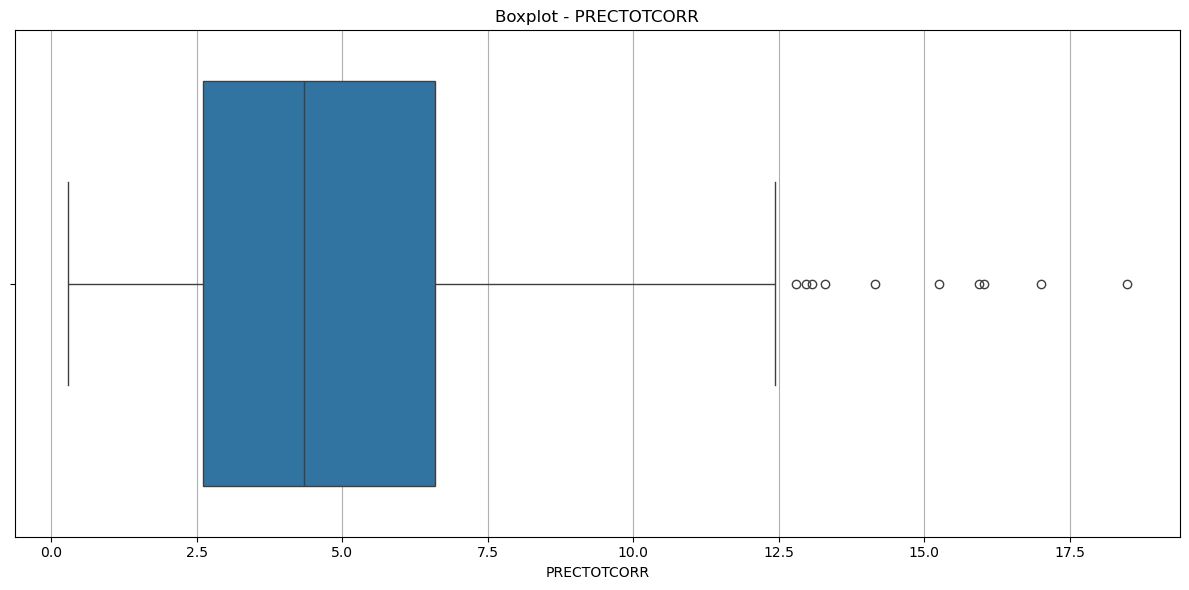

ValueError: List of boxplot statistics and `positions` values must have same the length

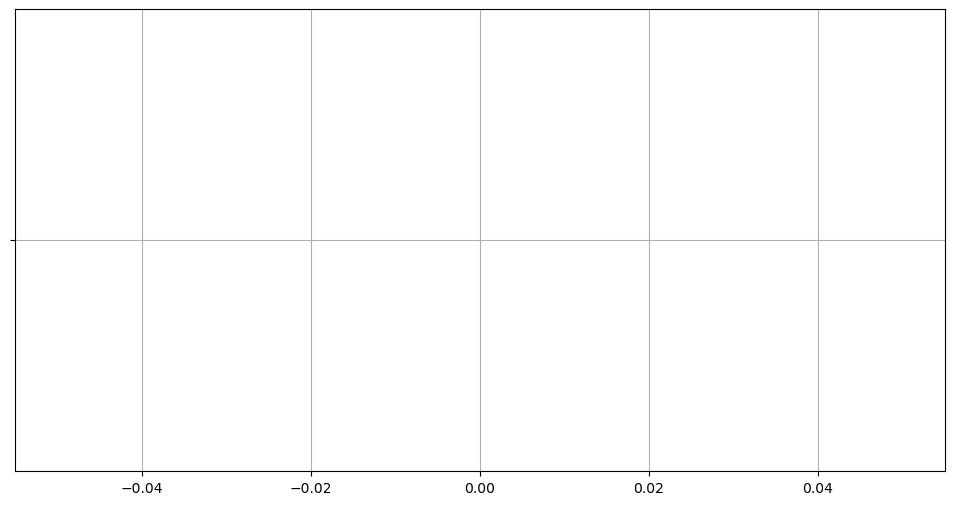

In [20]:
# ------------------------------------------------------
# 6. Boxplots (outliers)
# ------------------------------------------------------
for col in climate_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot - {col}")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

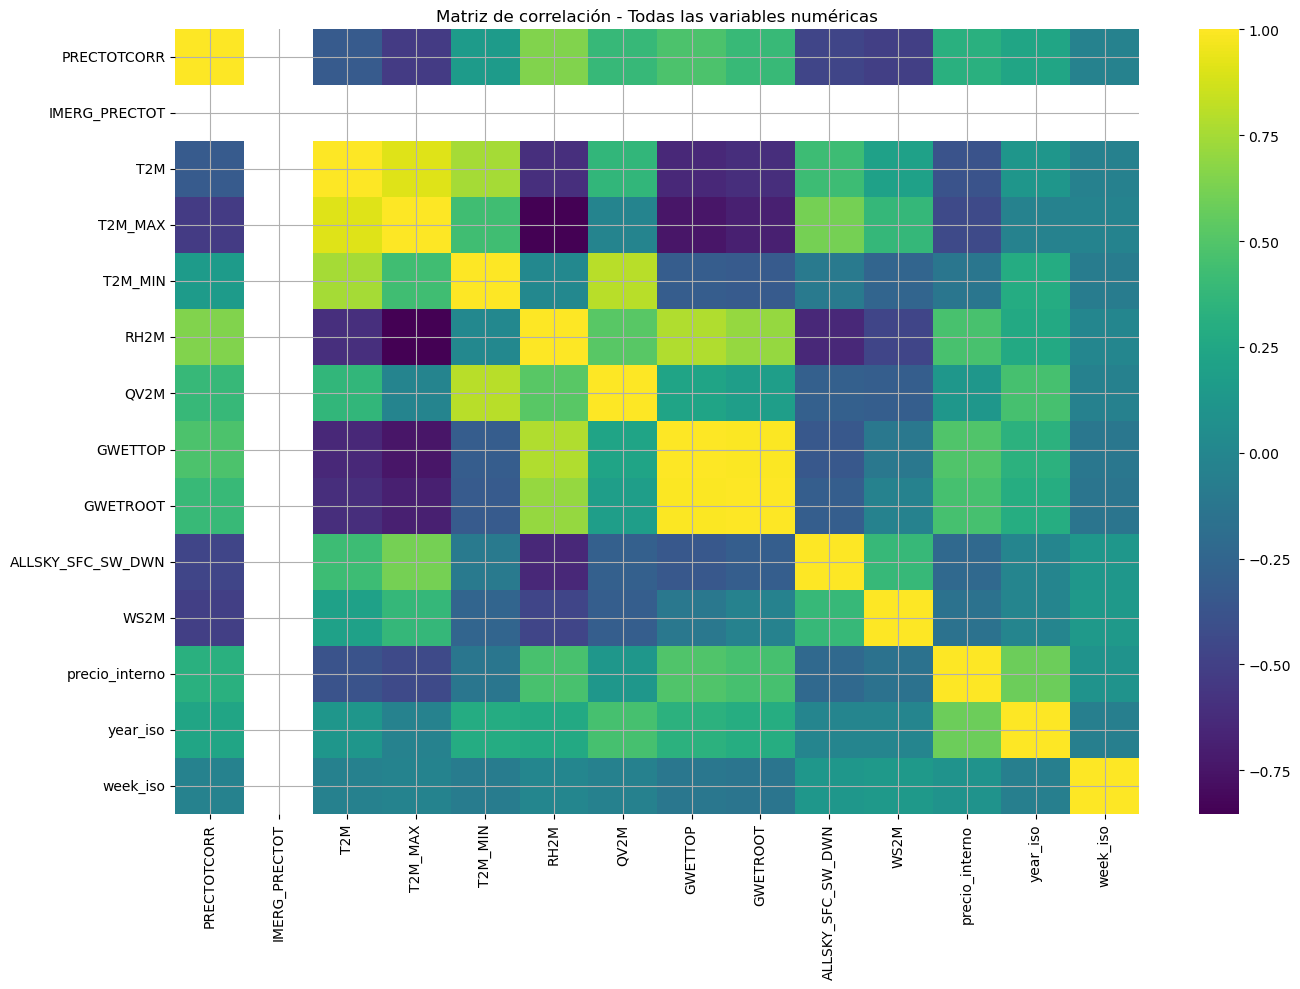


Matriz de correlación guardada como 'eda_correlaciones_completas.csv'


In [21]:

# ------------------------------------------------------
# 7. Matriz de correlación global
# ------------------------------------------------------
corr = df[num_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, annot=False, cmap="viridis")
plt.title("Matriz de correlación - Todas las variables numéricas")
plt.tight_layout()
plt.show()

corr.to_csv("eda_correlaciones_completas.csv")
print("\nMatriz de correlación guardada como 'eda_correlaciones_completas.csv'")


=== CORRELACIONES CON precio_interno ===
precio_interno       1.000000
year_iso             0.581551
GWETTOP              0.488715
RH2M                 0.461619
GWETROOT             0.456936
PRECTOTCORR          0.325216
QV2M                 0.129299
week_iso             0.097628
T2M_MIN             -0.128739
WS2M                -0.157350
ALLSKY_SFC_SW_DWN   -0.229229
T2M                 -0.379474
T2M_MAX             -0.437244
IMERG_PRECTOT             NaN
Name: precio_interno, dtype: float64


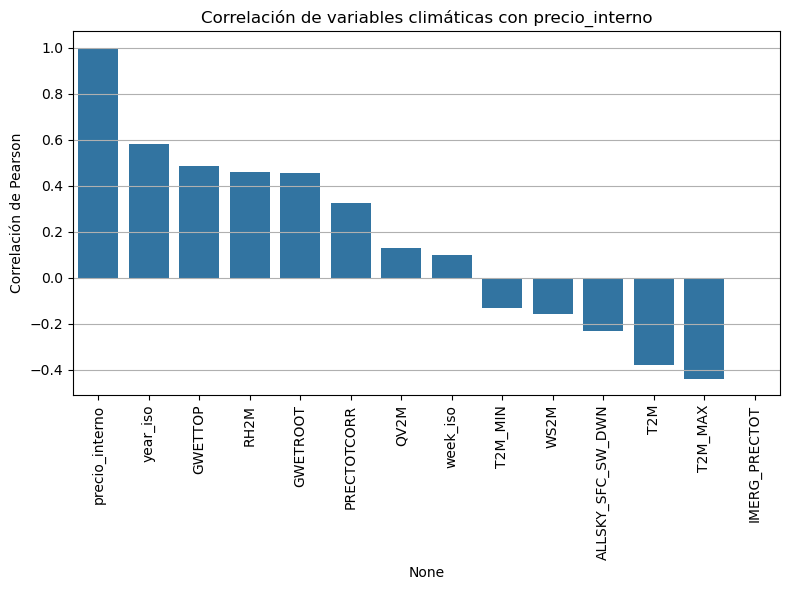

In [22]:

# ------------------------------------------------------
# 8. Correlaciones específicas con el precio interno
# ------------------------------------------------------
if precio_col:
    corr_precio = corr[precio_col].sort_values(ascending=False)
    print(f"\n=== CORRELACIONES CON {precio_col} ===")
    print(corr_precio)

    corr_precio.to_csv("eda_correlaciones_con_precio.csv")

    plt.figure(figsize=(8, 6))
    sns.barplot(x=corr_precio.index, y=corr_precio.values)
    plt.xticks(rotation=90)
    plt.title(f"Correlación de variables climáticas con {precio_col}")
    plt.ylabel("Correlación de Pearson")
    plt.tight_layout()
    plt.show()



=== CORRELACIÓN PRECIOS LAGGEADOS vs PRECTOTCORR ===
precio_interno_lag_1     0.354961
precio_interno_lag_4     0.366881
precio_interno_lag_8     0.317278
precio_interno_lag_26    0.305724
precio_interno_lag_39    0.127413
Name: PRECTOTCORR, dtype: float64


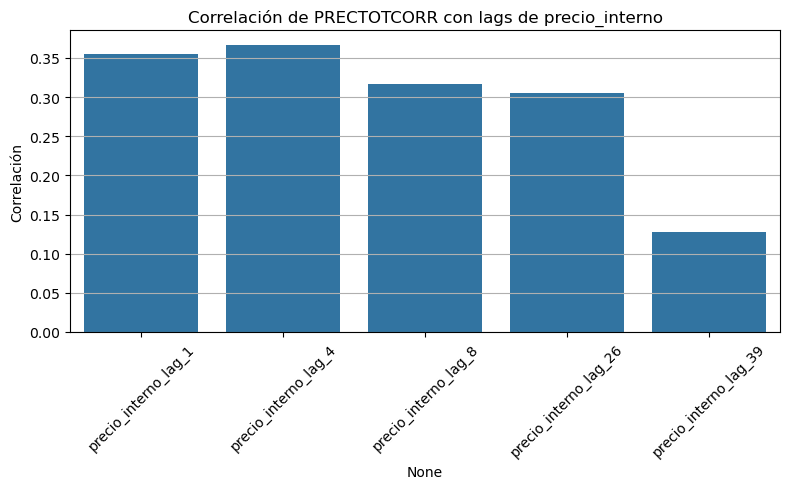

In [23]:

# ------------------------------------------------------
# 9. Rezagos (lags) precipitación vs precio interno
# ------------------------------------------------------
if precio_col and precip_col:
    for lag in [1, 4, 8, 26, 39]:  # semanas de rezago
        col_lag = f"{precio_col}_lag_{lag}"
        df[col_lag] = df[precio_col].shift(lag)

    lag_cols = [c for c in df.columns if "lag_" in c]
    corr_lags = df[[precip_col] + lag_cols].corr()[precip_col].drop(precip_col)
    
    print(f"\n=== CORRELACIÓN PRECIOS LAGGEADOS vs {precip_col} ===")
    print(corr_lags)

    plt.figure(figsize=(8, 5))
    sns.barplot(x=corr_lags.index, y=corr_lags.values)
    plt.xticks(rotation=45)
    plt.ylabel("Correlación")
    plt.title(f"Correlación de {precip_col} con lags de {precio_col}")
    plt.tight_layout()
    plt.show()

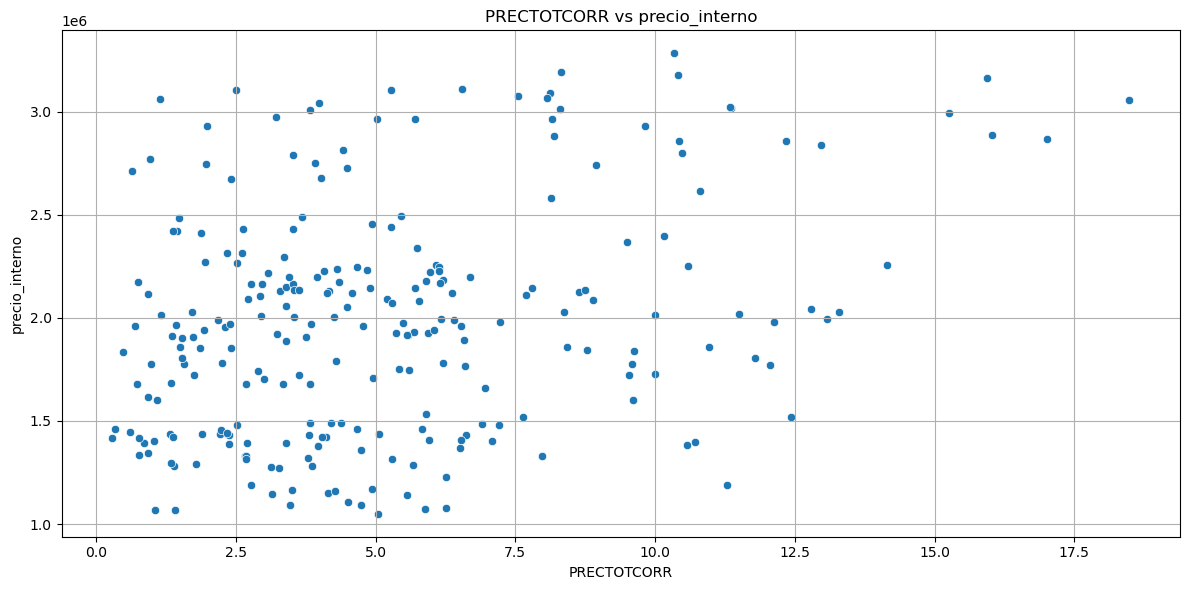

In [24]:

# ------------------------------------------------------
# 10. Scatter precipitación vs precio
# ------------------------------------------------------
if precio_col and precip_col:
    plt.figure()
    sns.scatterplot(x=df[precip_col], y=df[precio_col])
    plt.xlabel(precip_col)
    plt.ylabel(precio_col)
    plt.title(f"{precip_col} vs {precio_col}")
    plt.tight_layout()
    plt.show()


C:\Users\junio\AppData\Local\Temp\ipykernel_22532\770167356.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample('M')


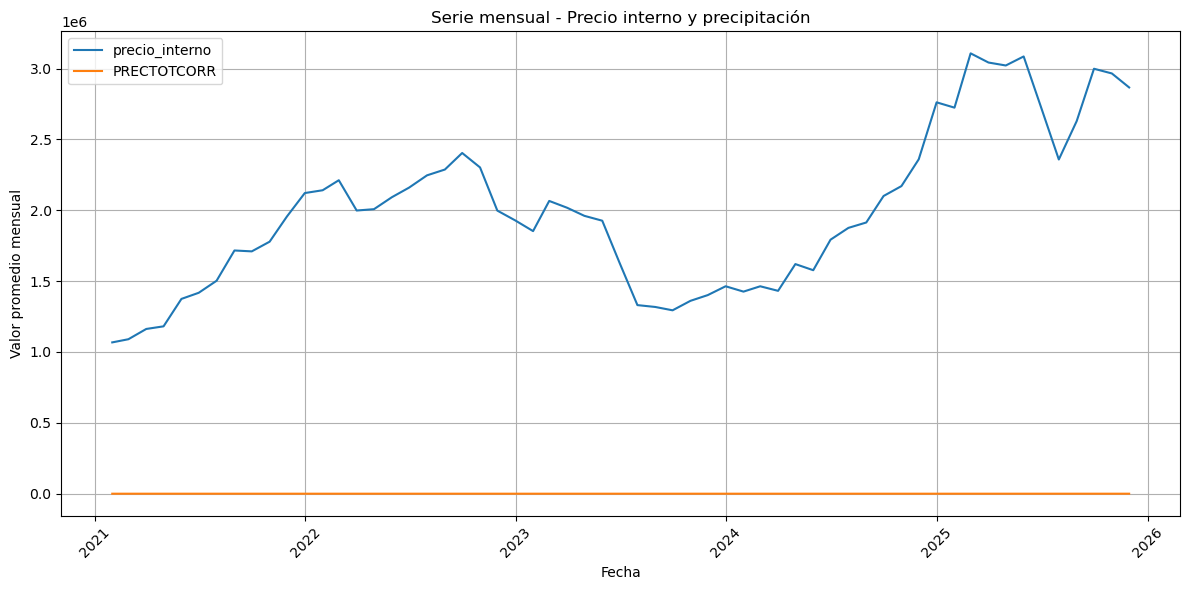


✅ EDA completo ejecutado. Revisa los gráficos y archivos .csv generados.


In [25]:

# ------------------------------------------------------
# 11. Agregaciones mensuales (opcional)
# ------------------------------------------------------
df_monthly = (
    df.set_index('fecha')
      .resample('M')
      .mean()
      .reset_index()
)

if precio_col and precip_col:
    plt.figure()
    plt.plot(df_monthly['fecha'], df_monthly[precio_col], label=precio_col)
    plt.plot(df_monthly['fecha'], df_monthly[precip_col], label=precip_col)
    plt.title("Serie mensual - Precio interno y precipitación")
    plt.xlabel("Fecha")
    plt.ylabel("Valor promedio mensual")
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

print("\n✅ EDA completo ejecutado. Revisa los gráficos y archivos .csv generados.")